In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.interpolate import UnivariateSpline
from sklearn.linear_model import LinearRegression

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

behave_df = pd.read_csv("/content/drive/MyDrive/Datasets/data.csv")
quest_df = pd.read_csv("/content/drive/MyDrive/Datasets/quest.csv")
info_df = pd.read_csv("/content/drive/MyDrive/Datasets/info.csv")

In [4]:
print("behave_df:", "subjectID" in behave_df.columns)
print("quest_df:", "subjectID" in quest_df.columns)
print("info_df:", "subjectID" in info_df.columns)

behave_df: True
quest_df: True
info_df: True


In [5]:
behave_df.head(5)

,Unnamed: 0,X,subjectID,assigned_condition,block_nr,trial_nr,grid,initial_opened,selected_choice,reward,average_reward,time_elapsed,rt,start_time,end_time
0,1,1001,44r44zmrtvl59ml3llcql4w4,NaN,0,0,51,111,101,56.861885,65.500000,45268,3932,30/08/2022 07:11:36,30/08/2022 07:16:32
1,2,1002,44r44zmrtvl59ml3llcql4w4,NaN,0,1,51,111,110,82.133990,71.000000,48531,3249,30/08/2022 07:11:36,30/08/2022 07:16:32
2,3,1003,44r44zmrtvl59ml3llcql4w4,NaN,0,2,51,111,101,57.101132,67.500000,50468,1930,30/08/2022 07:11:36,30/08/2022 07:16:32
3,4,1004,44r44zmrtvl59ml3llcql4w4,NaN,0,3,51,111,100,61.086212,66.200000,51964,1489,30/08/2022 07:11:36,30/08/2022 07:16:32
4,5,1005,44r44zmrtvl59ml3llcql4w4,NaN,0,4,51,111,99,70.195297,66.833333,53662,1690,30/08/2022 07:11:36,30/08/2022 07:16:32


In [6]:
quest_df.head(5)

,Unnamed: 0,subjectID,aq_tot,aq_tot_bin,asrs_tot,sds_tot,paq_tot,cati_tot
0,1,4rrw4vlw3mrs9v533ztqt4tq,NaN,NaN,NaN,NaN,NaN,NaN
1,2,4mrr4t6ww3s6tmsthrwqv4ss,NaN,NaN,NaN,NaN,NaN,NaN
2,3,45r34t4rh6445vs4h3mqt434,NaN,NaN,NaN,NaN,NaN,NaN
3,4,45r54c5m4cqzl3ctz9lqr4z3,91.0,12.0,41.0,34.0,127.0,NaN
4,5,lltv564rqmcvzqq9c3s5lmr9,134.0,31.0,55.0,45.0,110.0,NaN


In [7]:
info_df.head(5)

,Unnamed: 0,subjectID,group,prolific_study,ICAR_total,age,gender
0,1,4wrr9z6l5lclw9mcz4tv5qm6,control,wave1,7.0,24.0,Male
1,2,r5rv6zrvzlmlw9mczs66whwz,autism,wave1,6.0,31.0,Male
2,3,thrqhz49mlml39mczc356zt5,control,wave2,9.0,25.0,Male
3,4,rcrvrzh6ll3lmrmcz6zmh63s,control,wave2,7.0,35.0,Male
4,5,4qrwq53mslq4cr4vsrt6946c,control,pilot,7.0,32.0,Male


In [8]:
# behave = the participant's behaviors during the trials
# quest = participant's score from ASD & other disorders questionnaires
# info = particiipant's info

# We will merge them for a better look

asd_df = pd.merge(behave_df, quest_df, on="subjectID", how="left")
asd_df = pd.merge(asd_df, info_df, on="subjectID", how="left")

# Drop assigned_condition column since NULL & others(we use group column)
asd_df = asd_df.drop(columns=["assigned_condition"])

In [9]:
asd_df.columns

Index(['Unnamed: 0_x', 'X', 'subjectID', 'block_nr', 'trial_nr', 'grid',
       'initial_opened', 'selected_choice', 'reward', 'average_reward',
       'time_elapsed', 'rt', 'start_time', 'end_time', 'Unnamed: 0_y',
       'aq_tot', 'aq_tot_bin', 'asrs_tot', 'sds_tot', 'paq_tot', 'cati_tot',
       'Unnamed: 0', 'group', 'prolific_study', 'ICAR_total', 'age', 'gender'],
      dtype='object')

In [10]:
asd_df.head(5)

,Unnamed: 0_x,X,subjectID,block_nr,trial_nr,grid,initial_opened,selected_choice,reward,average_reward,...,asrs_tot,sds_tot,paq_tot,cati_tot,Unnamed: 0,group,prolific_study,ICAR_total,age,gender
0,1,1001,44r44zmrtvl59ml3llcql4w4,0,0,51,111,101,56.861885,65.500000,...,37.0,35.0,101.0,116.0,91,control,pilot,5.0,28.0,Female
1,2,1002,44r44zmrtvl59ml3llcql4w4,0,1,51,111,110,82.133990,71.000000,...,37.0,35.0,101.0,116.0,91,control,pilot,5.0,28.0,Female
2,3,1003,44r44zmrtvl59ml3llcql4w4,0,2,51,111,101,57.101132,67.500000,...,37.0,35.0,101.0,116.0,91,control,pilot,5.0,28.0,Female
3,4,1004,44r44zmrtvl59ml3llcql4w4,0,3,51,111,100,61.086212,66.200000,...,37.0,35.0,101.0,116.0,91,control,pilot,5.0,28.0,Female
4,5,1005,44r44zmrtvl59ml3llcql4w4,0,4,51,111,99,70.195297,66.833333,...,37.0,35.0,101.0,116.0,91,control,pilot,5.0,28.0,Female


In [11]:
def grid_to_xy(pos):
  x = pos % 11
  y = pos // 11
  return np.array([x, y])

# converts the index of 0-120 to the 11x11 grid

Let's take a look at a single participant.

We want to see their reward differences across trials and whether the next move they do, changes based on it.

In [12]:
pid = "44r44zmrtvl59ml3llcql4w4"
sub = asd_df[asd_df["subjectID"] == pid].copy()

# sort round and trial
sub = sub.sort_values(["block_nr", "trial_nr"]).reset_index(drop=True)

# define current tile, next tile, current reward and previous reward
sub["A_t"] = sub["selected_choice"]
sub["A_t+1"] = sub["selected_choice"].shift(-1)

sub["R_t"] = sub["reward"]
sub["R_t-1"] = sub["reward"].shift(1)


In [13]:
# grid distance calculator

def dist_tiles(a, b):
  if np.isnan(a) or np.isnan(b):
    return np.nan
  return np.linalg.norm(grid_to_xy(a) - grid_to_xy(b))

sub["Dist_a"] = [
    dist_tiles(a, b) for a, b in zip(sub["A_t"], sub["A_t+1"])
]

# delta reward (previous - current)
sub["Delta_R"] = sub["R_t"] - sub["R_t-1"]

In [14]:
# now we put it together

transition_df = sub[[
    "trial_nr",
    "A_t",
    "A_t+1",
    "Dist_a",
    "R_t",
    "R_t-1",
    "Delta_R",
    "block_nr"
]].rename(columns={
    "block_nr": "Round"
})

- A_t: current tile placement/location
- At-1: the NEXT tile location
- Dist_a: distance between At and At-1
- R_t: reward for that current trial
- R_t-1: reward for previous trial
- Delta_R: rt-1 - rt
Round (up to 10)


In [15]:
transition_df

,trial_nr,A_t,A_t+1,Dist_a,R_t,R_t-1,Delta_R,Round
0,0,101,110.0,2.236068,56.861885,NaN,NaN,0
1,1,110,101.0,2.236068,82.133990,56.861885,25.272105,0
2,2,101,100.0,1.000000,57.101132,82.133990,-25.032858,0
3,3,100,99.0,1.000000,61.086212,57.101132,3.985080,0
4,4,99,112.0,2.236068,70.195297,61.086212,9.109085,0
...,...,...,...,...,...,...,...,...
245,20,24,36.0,1.414214,40.021377,32.698821,7.322555,9
246,21,36,37.0,1.000000,46.221616,40.021377,6.200239,9
247,22,37,47.0,1.414214,41.592283,46.221616,-4.629333,9
248,23,47,60.0,2.236068,27.342691,41.592283,-14.249591,9


In [16]:
# Need to drop first and last row since NaN

transition_df = transition_df.dropna().reset_index(drop=True)


In [17]:
transition_df

,trial_nr,A_t,A_t+1,Dist_a,R_t,R_t-1,Delta_R,Round
0,1,110,101.0,2.236068,82.133990,56.861885,25.272105,0
1,2,101,100.0,1.000000,57.101132,82.133990,-25.032858,0
2,3,100,99.0,1.000000,61.086212,57.101132,3.985080,0
3,4,99,112.0,2.236068,70.195297,61.086212,9.109085,0
4,5,112,113.0,1.000000,69.173351,70.195297,-1.021947,0
...,...,...,...,...,...,...,...,...
243,19,13,24.0,1.000000,32.698821,42.473793,-9.774972,9
244,20,24,36.0,1.414214,40.021377,32.698821,7.322555,9
245,21,36,37.0,1.000000,46.221616,40.021377,6.200239,9
246,22,37,47.0,1.414214,41.592283,46.221616,-4.629333,9


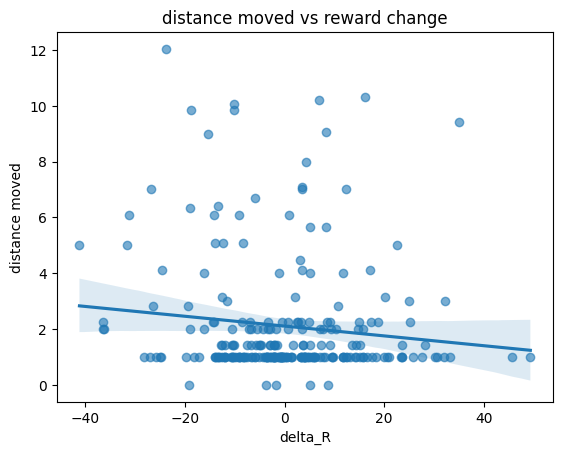

In [18]:
# we know that this participant is in the lower quartile
# according to the AQ, let's test something

plt.figure()
sns.regplot(data=transition_df, x="Delta_R", y="Dist_a", scatter_kws={"alpha":0.6})

plt.xlabel("delta_R")
plt.ylabel("distance moved")
plt.title("distance moved vs reward change")
plt.show()

looks like this participant has low reward sensitivity:

- as the reward gets better, they tend to travel greater

- moving more based on uncertainty

Overall, it looks like it works, let's turn it into a function.

In [19]:
def make_transition_df(pid, df=asd_df, grid_size=11):

  sub = df[df["subjectID"] == pid].copy()
  if sub.empty:
    return pd.DataFrame() # returns empty if no subject

  # sort block and trials for subject
  sub = sub.sort_values(["block_nr", "trial_nr"]).reset_index(drop=True)

  # current tile, next tile, current reward, prev reward

  sub["A_t"] = sub["selected_choice"]
  sub["A_t+1"] = sub["selected_choice"].shift(-1)

  sub["R_t"] = sub["reward"]
  sub["R_t-1"] = sub["reward"].shift(1)

  # distance traveled for subject
  sub["Dist_a"] = [dist_tiles(a, b) for a, b in zip(sub["A_t"], sub["A_t+1"])]

  # reward change or difference
  sub["Delta_R"] = sub["R_t"] - sub["R_t-1"]


  # putting it all together
  output = sub[[
        "trial_nr", "A_t", "A_t+1", "Dist_a",
        "R_t", "R_t-1", "Delta_R", "block_nr", "aq_tot", "aq_tot_bin", "group"
    ]].rename(columns={"trial_nr": "trial", "block_nr": "Round"})

  output.insert(0, "subjectID", pid)

  # Drop rows that are empty
  output = output.dropna().reset_index(drop=True)
  return output

In [20]:
# testing
random_participant = make_transition_df("6mtzhvrqrcs3rq3vhhrr5c43", asd_df)

random_participant

,subjectID,trial,A_t,A_t+1,Dist_a,R_t,R_t-1,Delta_R,Round,aq_tot,aq_tot_bin,group
0,6mtzhvrqrcs3rq3vhhrr5c43,1,107,96.0,1.000000,33.996040,37.992839,-3.996799,0,83.0,10.0,control
1,6mtzhvrqrcs3rq3vhhrr5c43,2,96,97.0,1.000000,31.274705,33.996040,-2.721335,0,83.0,10.0,control
2,6mtzhvrqrcs3rq3vhhrr5c43,3,97,109.0,1.414214,31.883151,31.274705,0.608445,0,83.0,10.0,control
3,6mtzhvrqrcs3rq3vhhrr5c43,4,109,84.0,3.605551,35.821491,31.883151,3.938341,0,83.0,10.0,control
4,6mtzhvrqrcs3rq3vhhrr5c43,5,84,72.0,1.414214,32.924410,35.821491,-2.897081,0,83.0,10.0,control
...,...,...,...,...,...,...,...,...,...,...,...,...
243,6mtzhvrqrcs3rq3vhhrr5c43,19,29,50.0,2.236068,64.848428,73.075206,-8.226778,9,83.0,10.0,control
244,6mtzhvrqrcs3rq3vhhrr5c43,20,50,39.0,1.000000,55.153846,64.848428,-9.694582,9,83.0,10.0,control
245,6mtzhvrqrcs3rq3vhhrr5c43,21,39,30.0,2.236068,62.803955,55.153846,7.650109,9,83.0,10.0,control
246,6mtzhvrqrcs3rq3vhhrr5c43,22,30,31.0,1.000000,60.796030,62.803955,-2.007925,9,83.0,10.0,control


It works!

In [21]:
# Let's try it on a control participant
# Need to split based on control and autism

autism_df = asd_df[asd_df["group"] == "autism"]
control_df = asd_df[asd_df["group"] == "control"]

print("Autism subjects:", autism_df["subjectID"].nunique())
print("Control subjects:", control_df["subjectID"].nunique())


Autism subjects: 77
Control subjects: 511


In [22]:
autism_df.head(5)

,Unnamed: 0_x,X,subjectID,block_nr,trial_nr,grid,initial_opened,selected_choice,reward,average_reward,...,asrs_tot,sds_tot,paq_tot,cati_tot,Unnamed: 0,group,prolific_study,ICAR_total,age,gender
9500,9501,12001,twtzmvq9639ts49wll9c65hq,0,0,31,12,13,58.286300,54.50,...,47.0,63.0,41.0,207.0,340,autism,wave1,13.0,27.0,Female
9501,9502,12002,twtzmvq9639ts49wll9c65hq,0,1,31,12,24,38.269079,49.00,...,47.0,63.0,41.0,207.0,340,autism,wave1,13.0,27.0,Female
9502,9503,12003,twtzmvq9639ts49wll9c65hq,0,2,31,12,2,69.875757,54.25,...,47.0,63.0,41.0,207.0,340,autism,wave1,13.0,27.0,Female
9503,9504,12004,twtzmvq9639ts49wll9c65hq,0,3,31,12,1,66.020061,56.60,...,47.0,63.0,41.0,207.0,340,autism,wave1,13.0,27.0,Female
9504,9505,12005,twtzmvq9639ts49wll9c65hq,0,4,31,12,0,58.903365,57.00,...,47.0,63.0,41.0,207.0,340,autism,wave1,13.0,27.0,Female


In [23]:
control_df.head(5)

,Unnamed: 0_x,X,subjectID,block_nr,trial_nr,grid,initial_opened,selected_choice,reward,average_reward,...,asrs_tot,sds_tot,paq_tot,cati_tot,Unnamed: 0,group,prolific_study,ICAR_total,age,gender
0,1,1001,44r44zmrtvl59ml3llcql4w4,0,0,51,111,101,56.861885,65.500000,...,37.0,35.0,101.0,116.0,91,control,pilot,5.0,28.0,Female
1,2,1002,44r44zmrtvl59ml3llcql4w4,0,1,51,111,110,82.133990,71.000000,...,37.0,35.0,101.0,116.0,91,control,pilot,5.0,28.0,Female
2,3,1003,44r44zmrtvl59ml3llcql4w4,0,2,51,111,101,57.101132,67.500000,...,37.0,35.0,101.0,116.0,91,control,pilot,5.0,28.0,Female
3,4,1004,44r44zmrtvl59ml3llcql4w4,0,3,51,111,100,61.086212,66.200000,...,37.0,35.0,101.0,116.0,91,control,pilot,5.0,28.0,Female
4,5,1005,44r44zmrtvl59ml3llcql4w4,0,4,51,111,99,70.195297,66.833333,...,37.0,35.0,101.0,116.0,91,control,pilot,5.0,28.0,Female


In [24]:
autism_part = make_transition_df("twtzmvq9639ts49wll9c65hq", autism_df)

autism_part


,subjectID,trial,A_t,A_t+1,Dist_a,R_t,R_t-1,Delta_R,Round,aq_tot,aq_tot_bin,group
0,twtzmvq9639ts49wll9c65hq,1,24,2.0,2.0,38.269079,58.286300,-20.017221,0,176.0,44.0,autism
1,twtzmvq9639ts49wll9c65hq,2,2,1.0,1.0,69.875757,38.269079,31.606678,0,176.0,44.0,autism
2,twtzmvq9639ts49wll9c65hq,3,1,0.0,1.0,66.020061,69.875757,-3.855695,0,176.0,44.0,autism
3,twtzmvq9639ts49wll9c65hq,4,0,3.0,3.0,58.903365,66.020061,-7.116697,0,176.0,44.0,autism
4,twtzmvq9639ts49wll9c65hq,5,3,4.0,1.0,65.541003,58.903365,6.637639,0,176.0,44.0,autism
...,...,...,...,...,...,...,...,...,...,...,...,...
243,twtzmvq9639ts49wll9c65hq,19,78,78.0,0.0,78.013380,76.262805,1.750575,9,176.0,44.0,autism
244,twtzmvq9639ts49wll9c65hq,20,78,78.0,0.0,75.848780,78.013380,-2.164600,9,176.0,44.0,autism
245,twtzmvq9639ts49wll9c65hq,21,78,78.0,0.0,77.024325,75.848780,1.175545,9,176.0,44.0,autism
246,twtzmvq9639ts49wll9c65hq,22,78,78.0,0.0,77.324110,77.024325,0.299785,9,176.0,44.0,autism


In [25]:
control_part = make_transition_df("44r44zmrtvl59ml3llcql4w4", control_df)

control_part

,subjectID,trial,A_t,A_t+1,Dist_a,R_t,R_t-1,Delta_R,Round,aq_tot,aq_tot_bin,group
0,44r44zmrtvl59ml3llcql4w4,1,110,101.0,2.236068,82.133990,56.861885,25.272105,0,103.0,16.0,control
1,44r44zmrtvl59ml3llcql4w4,2,101,100.0,1.000000,57.101132,82.133990,-25.032858,0,103.0,16.0,control
2,44r44zmrtvl59ml3llcql4w4,3,100,99.0,1.000000,61.086212,57.101132,3.985080,0,103.0,16.0,control
3,44r44zmrtvl59ml3llcql4w4,4,99,112.0,2.236068,70.195297,61.086212,9.109085,0,103.0,16.0,control
4,44r44zmrtvl59ml3llcql4w4,5,112,113.0,1.000000,69.173351,70.195297,-1.021947,0,103.0,16.0,control
...,...,...,...,...,...,...,...,...,...,...,...,...
243,44r44zmrtvl59ml3llcql4w4,19,13,24.0,1.000000,32.698821,42.473793,-9.774972,9,103.0,16.0,control
244,44r44zmrtvl59ml3llcql4w4,20,24,36.0,1.414214,40.021377,32.698821,7.322555,9,103.0,16.0,control
245,44r44zmrtvl59ml3llcql4w4,21,36,37.0,1.000000,46.221616,40.021377,6.200239,9,103.0,16.0,control
246,44r44zmrtvl59ml3llcql4w4,22,37,47.0,1.414214,41.592283,46.221616,-4.629333,9,103.0,16.0,control


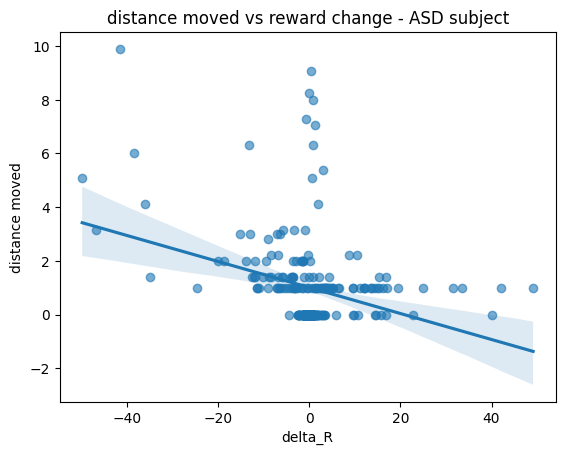

In [26]:
plt.figure()
sns.regplot(data=autism_part, x="Delta_R", y="Dist_a", scatter_kws={"alpha":0.6})

plt.xlabel("delta_R")
plt.ylabel("distance moved")
plt.title("distance moved vs reward change - ASD subject")
plt.show()

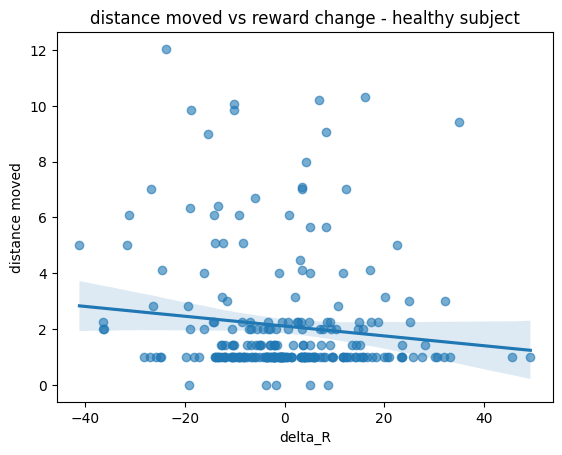

In [27]:
plt.figure()
sns.regplot(data=control_part, x="Delta_R", y="Dist_a", scatter_kws={"alpha":0.6})

plt.xlabel("delta_R")
plt.ylabel("distance moved")
plt.title("distance moved vs reward change - healthy subject")
plt.show()

This is interesting, we see that a participant with ASD tends to explore less novel choices given their reward differences.

In contrast, a healthy participant explores more, being more sensitive to reward aflucutations, with their choices spreading beyond their previous decisions.

Maybe we can look at a Low AQ vs High AQ participant?

In [28]:
lowest_row = asd_df.loc[asd_df["aq_tot"].idxmin()]
lowest_id = lowest_row["subjectID"]

print(lowest_id, lowest_row["aq_tot"])


highest_row = asd_df.loc[asd_df["aq_tot"].idxmax()]
highest_id = highest_row["subjectID"]

print(highest_id, highest_row["aq_tot"])


4qr5vs46wz6lqz4vmsl6wc3r 69.0
hmt5r5q6r4q464zctmc4chm4 184.0


In [29]:
low_aq = make_transition_df("4qr5vs46wz6lqz4vmsl6wc3r", asd_df)

high_aq = make_transition_df("hmt5r5q6r4q464zctmc4chm4", asd_df)

low_aq.head(5)

,subjectID,trial,A_t,A_t+1,Dist_a,R_t,R_t-1,Delta_R,Round,aq_tot,aq_tot_bin,group
0,4qr5vs46wz6lqz4vmsl6wc3r,1,13,2.0,1.0,25.027440,7.397990,17.629450,0,69.0,2.0,control
1,4qr5vs46wz6lqz4vmsl6wc3r,2,2,3.0,1.0,41.054155,25.027440,16.026715,0,69.0,2.0,control
2,4qr5vs46wz6lqz4vmsl6wc3r,3,3,4.0,1.0,45.823596,41.054155,4.769441,0,69.0,2.0,control
3,4qr5vs46wz6lqz4vmsl6wc3r,4,4,5.0,1.0,50.940318,45.823596,5.116722,0,69.0,2.0,control
4,4qr5vs46wz6lqz4vmsl6wc3r,5,5,6.0,1.0,56.309404,50.940318,5.369085,0,69.0,2.0,control


In [30]:
high_aq.head(5)

,subjectID,trial,A_t,A_t+1,Dist_a,R_t,R_t-1,Delta_R,Round,aq_tot,aq_tot_bin,group
0,hmt5r5q6r4q464zctmc4chm4,1,24,36.0,1.414214,41.563417,39.535232,2.028185,0,184.0,47.0,autism
1,hmt5r5q6r4q464zctmc4chm4,2,36,22.0,3.162278,27.160129,41.563417,-14.403287,0,184.0,47.0,autism
2,hmt5r5q6r4q464zctmc4chm4,3,22,23.0,1.000000,41.227361,27.160129,14.067231,0,184.0,47.0,autism
3,hmt5r5q6r4q464zctmc4chm4,4,23,12.0,1.000000,45.868311,41.227361,4.640950,0,184.0,47.0,autism
4,hmt5r5q6r4q464zctmc4chm4,5,12,1.0,1.000000,56.287826,45.868311,10.419516,0,184.0,47.0,autism


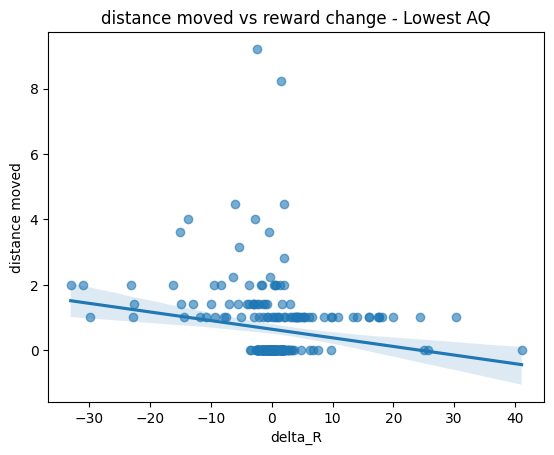

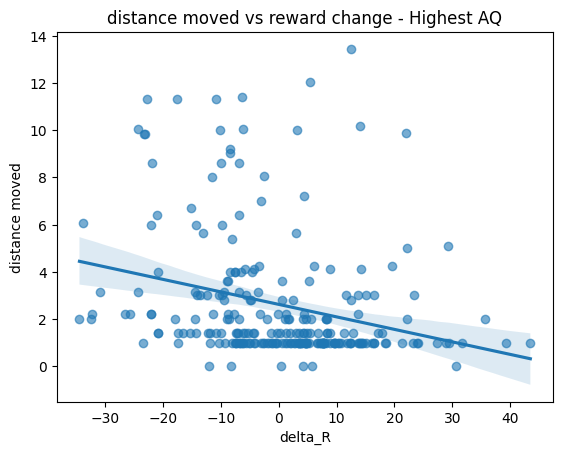

In [31]:
plt.figure()
sns.regplot(data=low_aq, x="Delta_R", y="Dist_a", scatter_kws={"alpha":0.6})

plt.xlabel("delta_R")
plt.ylabel("distance moved")
plt.title("distance moved vs reward change - Lowest AQ")
plt.show()

plt.figure()
sns.regplot(data=high_aq, x="Delta_R", y="Dist_a", scatter_kws={"alpha":0.6})

plt.xlabel("delta_R")
plt.ylabel("distance moved")
plt.title("distance moved vs reward change - Highest AQ")
plt.show()

Doesn't seem to substantially diff compared to our first 2 participants.

We'll need more information, and better visualization. Lines aren't capture the trend as well.

In [32]:
autism_part

,subjectID,trial,A_t,A_t+1,Dist_a,R_t,R_t-1,Delta_R,Round,aq_tot,aq_tot_bin,group
0,twtzmvq9639ts49wll9c65hq,1,24,2.0,2.0,38.269079,58.286300,-20.017221,0,176.0,44.0,autism
1,twtzmvq9639ts49wll9c65hq,2,2,1.0,1.0,69.875757,38.269079,31.606678,0,176.0,44.0,autism
2,twtzmvq9639ts49wll9c65hq,3,1,0.0,1.0,66.020061,69.875757,-3.855695,0,176.0,44.0,autism
3,twtzmvq9639ts49wll9c65hq,4,0,3.0,3.0,58.903365,66.020061,-7.116697,0,176.0,44.0,autism
4,twtzmvq9639ts49wll9c65hq,5,3,4.0,1.0,65.541003,58.903365,6.637639,0,176.0,44.0,autism
...,...,...,...,...,...,...,...,...,...,...,...,...
243,twtzmvq9639ts49wll9c65hq,19,78,78.0,0.0,78.013380,76.262805,1.750575,9,176.0,44.0,autism
244,twtzmvq9639ts49wll9c65hq,20,78,78.0,0.0,75.848780,78.013380,-2.164600,9,176.0,44.0,autism
245,twtzmvq9639ts49wll9c65hq,21,78,78.0,0.0,77.024325,75.848780,1.175545,9,176.0,44.0,autism
246,twtzmvq9639ts49wll9c65hq,22,78,78.0,0.0,77.324110,77.024325,0.299785,9,176.0,44.0,autism


In [33]:
control_part

,subjectID,trial,A_t,A_t+1,Dist_a,R_t,R_t-1,Delta_R,Round,aq_tot,aq_tot_bin,group
0,44r44zmrtvl59ml3llcql4w4,1,110,101.0,2.236068,82.133990,56.861885,25.272105,0,103.0,16.0,control
1,44r44zmrtvl59ml3llcql4w4,2,101,100.0,1.000000,57.101132,82.133990,-25.032858,0,103.0,16.0,control
2,44r44zmrtvl59ml3llcql4w4,3,100,99.0,1.000000,61.086212,57.101132,3.985080,0,103.0,16.0,control
3,44r44zmrtvl59ml3llcql4w4,4,99,112.0,2.236068,70.195297,61.086212,9.109085,0,103.0,16.0,control
4,44r44zmrtvl59ml3llcql4w4,5,112,113.0,1.000000,69.173351,70.195297,-1.021947,0,103.0,16.0,control
...,...,...,...,...,...,...,...,...,...,...,...,...
243,44r44zmrtvl59ml3llcql4w4,19,13,24.0,1.000000,32.698821,42.473793,-9.774972,9,103.0,16.0,control
244,44r44zmrtvl59ml3llcql4w4,20,24,36.0,1.414214,40.021377,32.698821,7.322555,9,103.0,16.0,control
245,44r44zmrtvl59ml3llcql4w4,21,36,37.0,1.000000,46.221616,40.021377,6.200239,9,103.0,16.0,control
246,44r44zmrtvl59ml3llcql4w4,22,37,47.0,1.414214,41.592283,46.221616,-4.629333,9,103.0,16.0,control


In [34]:
# let's split participants into quartiles based on AQ (4 blocks)

aq_df = asd_df[["subjectID", "aq_tot"]].drop_duplicates()

aq_df["AQ_quartile"] = pd.qcut(
    aq_df["aq_tot"],
    q=4,
    labels=["Q1_low", "Q2_midlow", "Q3_midhigh", "Q4_high"]
)

In [35]:
def quartile_participant_averages(asd_df, aq_df, quartile):
    pids = aq_df.loc[aq_df["AQ_quartile"] == quartile, "subjectID"].dropna().unique()

    rows = []
    for pid in pids:
        # Corrected function call: changed `transition_df` to `make_transition_df`
        mat = make_transition_df(pid, asd_df)  # Assuming asd_df is the default argument for df
        if mat.empty:
            continue

        rows.append({
            "subjectID": pid,
            "mean_Dist_a": mat["Dist_a"].mean(),
            "mean_Delta_R": mat["Delta_R"].mean(),
            "n_transitions": len(mat)
        })

    per_participant_df = pd.DataFrame(rows)

    if not per_participant_df.empty:
        quartile_mean_dist = per_participant_df["mean_Dist_a"].mean()
        quartile_mean_delta_r = per_participant_df["mean_Delta_R"].mean()
    else:
        quartile_mean_dist = np.nan # Or handle as appropriate for empty data
        quartile_mean_delta_r = np.nan

    return quartile_mean_dist, quartile_mean_delta_r, per_participant_df


In [36]:
q = "Q1_low"  # lowest AQ quartile
mean_dist, mean_delta_r, per_participant_q1 = quartile_participant_averages(asd_df, aq_df, q)

print("Mean for ", q,  "Dist_a: ", mean_dist)
print("Mean for ", q,  "Delta_R: ", mean_delta_r)

per_participant_q1.head()

Mean for  Q1_low Dist_a:  1.7215725135794762
Mean for  Q1_low Delta_R:  0.07043606365228443


,subjectID,mean_Dist_a,mean_Delta_R,n_transitions
0,44r44zmrtvl59ml3llcql4w4,2.106032,-0.119029,248
1,sstr63rwvsmz36hmqs6hzzvs,1.638066,-0.057058,248
2,4qrwq53mslq4cr4vsrt6946c,0.528045,0.062387,248
3,6mtzhvrqrcs3rq3vhhrr5c43,2.068538,0.037244,248
4,5ctz9lwc6rt9c64rztwr6rzm,2.612953,0.015129,248


In [37]:
q = "Q2_midlow"  # 2nd mid AQ quartile
mean_dist, mean_delta_r, per_participant_q2 = quartile_participant_averages(asd_df, aq_df, q)

print("Mean for ", q,  "Dist_a: ", mean_dist)
print("Mean for ", q,  "Delta_R: ", mean_delta_r)

per_participant_q2.head()

Mean for  Q2_midlow Dist_a:  1.7468894245092064
Mean for  Q2_midlow Delta_R:  0.08237812129183361


,subjectID,mean_Dist_a,mean_Delta_R,n_transitions
0,tstr6t4hc5s3z6r4vmhz366q,1.066238,0.095133,248
1,w6t369hrcqztq4994tvhmmzr,1.320679,0.060962,248
2,4rrm4tcchtl49z3w3z63h4v6,1.049200,0.174240,248
3,4tr9q9qmszw33vhmv33t54w4,1.702304,0.102110,248
4,qht6z65mss65t4rmq9llszth,1.135600,0.239391,248


In [38]:
q = "Q3_midhigh"  # 3rd mid AQ quartile
mean_dist, mean_delta_r, per_participant_q3 = quartile_participant_averages(asd_df, aq_df, q)

print("Mean for ", q,  "Dist_a: ", mean_dist)
print("Mean for ", q,  "Delta_R: ", mean_delta_r)

per_participant_q3.head()

Mean for  Q3_midhigh Dist_a:  1.7353695370154367
Mean for  Q3_midhigh Delta_R:  0.07674988381831496


,subjectID,mean_Dist_a,mean_Delta_R,n_transitions
0,43rzq63t93hsl5ccc9369s5z,1.414735,0.012753,248
1,4zr94h9h9369rmm6h6lq349v,1.062684,0.028549,248
2,mvtr3v5q95zl6qlv4ws93tcs,2.120095,0.093653,248
3,lzrhwclcm4mlvc9lmvlwswht,2.471856,-0.112729,248
4,4wrz49rt3wv4qvm36r5q649z,2.213868,0.183346,248


In [39]:
q = "Q4_high"  # highest AQ quartile
mean_dist, mean_delta_r, per_participant_q4 = quartile_participant_averages(asd_df, aq_df, q)

print("Mean for ", q,  "Dist_a: ", mean_dist)
print("Mean for ", q,  "Delta_R: ", mean_delta_r)

per_participant_q4.head()

Mean for  Q4_high Dist_a:  1.6757017963440806
Mean for  Q4_high Delta_R:  0.08257387217208


,subjectID,mean_Dist_a,mean_Delta_R,n_transitions
0,4ztz9cwlhttm9qqh4tmvwc5h,2.080124,0.009946,248
1,4sr34wwcvzvr33l9t4vq64l4,1.931782,-0.024973,248
2,qzr5q3z6vsvwl5m9z34zz3hw,1.929556,0.039953,248
3,45r94sc4rsvlt3hhqs4q345m,0.357124,0.100279,248
4,twtzmvq9639ts49wll9c65hq,1.005593,0.074508,248


Seems in line with what we expect, though the differences aren't significant enough.

But, maybe we can better visualize this with a different plot to better capture a participant's movement.

In [40]:
def binned_curve_fast(x, y, bin_edges, min_bin_n=1):
    """
    Fast equal-width bin means using numpy only.

    Parameters
    ----------
    x, y : 1D arrays
    bin_edges : 1D array of length (n_bins+1)
    min_bin_n : int, bins with fewer points are dropped

    Returns
    -------
    centers : 1D array of bin centers (kept bins only)
    mean_y  : 1D array of mean y per kept bin
    counts  : 1D array of counts per kept bin
    """
    x = np.asarray(x)
    y = np.asarray(y)

    # keep finite pairs only
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    n_bins = len(bin_edges) - 1
    if len(x) == 0 or n_bins <= 0:
        return np.array([]), np.array([]), np.array([])

    # assign each x to a bin index in [0, n_bins-1]
    # digitize returns 1..n_bins (and 0 / n_bins+1 for out of range)
    idx = np.digitize(x, bin_edges) - 1
    in_range = (idx >= 0) & (idx < n_bins)
    idx = idx[in_range]
    y = y[in_range]

    # compute sums and counts per bin
    counts = np.bincount(idx, minlength=n_bins)
    sums = np.bincount(idx, weights=y, minlength=n_bins)

    # means (avoid divide-by-zero)
    means = np.divide(sums, counts, out=np.full(n_bins, np.nan), where=counts > 0)

    # bin centers
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # apply min_bin_n filter
    keep = counts >= min_bin_n
    return centers[keep], means[keep], counts[keep]

In [41]:
def plot_binned_single_participant_fast(
    df_sub,
    x_col="Delta_R",
    y_col="Dist_a",
    bin_edges=None,
    n_bins=15,
    x_range=None,
    min_bin_n=1,
    show_scatter=True,
    scatter_alpha=0.25,
    scatter_size=25,
    line_width=3,
    point_size=90,
    title=None,
):
    """
    Plot binned curve for a single participant. Optionally overlays scatter.
    Runtime-optimized (numpy binning).
    """
    x = df_sub[x_col].to_numpy()
    y = df_sub[y_col].to_numpy()

    # choose tail-preserving bin edges
    if bin_edges is None:
        if x_range is None:
            xmin = np.nanmin(x)
            xmax = np.nanmax(x)
        else:
            xmin, xmax = x_range
        if not np.isfinite(xmin) or not np.isfinite(xmax) or xmin == xmax:
            xmin, xmax = -1, 1
        bin_edges = np.linspace(xmin, xmax, n_bins + 1)
    else:
        bin_edges = np.asarray(bin_edges, dtype=float)

    centers, mean_y, counts = binned_curve_fast(x, y, bin_edges, min_bin_n=min_bin_n)

    plt.figure(figsize=(7, 5))

    if show_scatter:
        plt.scatter(x, y, alpha=scatter_alpha, s=scatter_size)

    plt.plot(centers, mean_y, linewidth=line_width)
    plt.scatter(centers, mean_y, s=point_size, zorder=3)

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.ylim(0, 15)
    if title is not None:
        plt.title(title)
    plt.show()

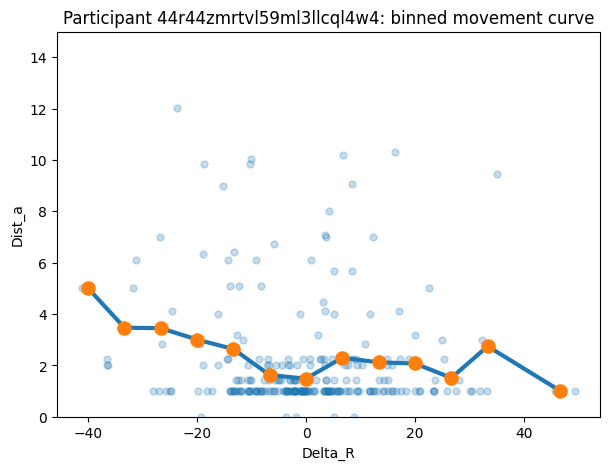

In [42]:
pid = "44r44zmrtvl59ml3llcql4w4"
mat = make_transition_df(pid, df=control_df)

individual_edges = np.linspace(-50, 50, 16)

out = plot_binned_single_participant_fast(
    mat,
    x_col="Delta_R",
    y_col="Dist_a",
    bin_edges=individual_edges,   # consistent across people/groups
    min_bin_n=1,              # keep tails even if sparse
    show_scatter=True,
    title=f"Participant {pid}: binned movement curve"
)

In [43]:
autism_ids = autism_df["subjectID"].unique().tolist()
autism_ids[:5]

['twtzmvq9639ts49wll9c65hq',
 'qrrzt3mq4ztmmztzszmqsm4s',
 '5stvthw4vthstq635l6ww4w9',
 'chtqwhc4shqmc49ztq9lsthv',
 '6sr9zq3clcw4rzlt5m4wqcc6']

In [44]:
control_ids = control_df["subjectID"].unique().tolist()
control_ids[:5]

['44r44zmrtvl59ml3llcql4w4',
 'sstr63rwvsmz36hmqs6hzzvs',
 '4qrwq53mslq4cr4vsrt6946c',
 '43rzq63t93hsl5ccc9369s5z',
 '6mtzhvrqrcs3rq3vhhrr5c43']

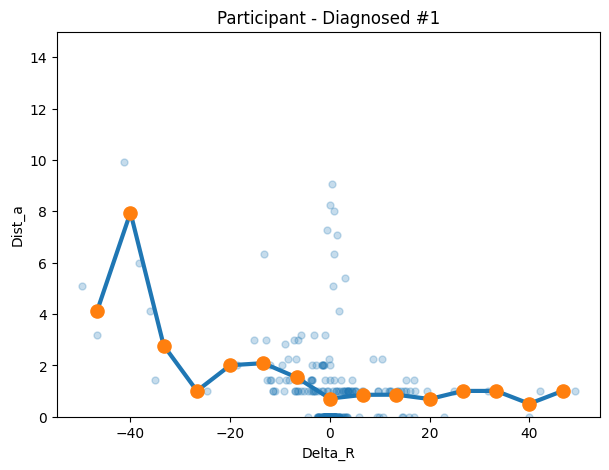

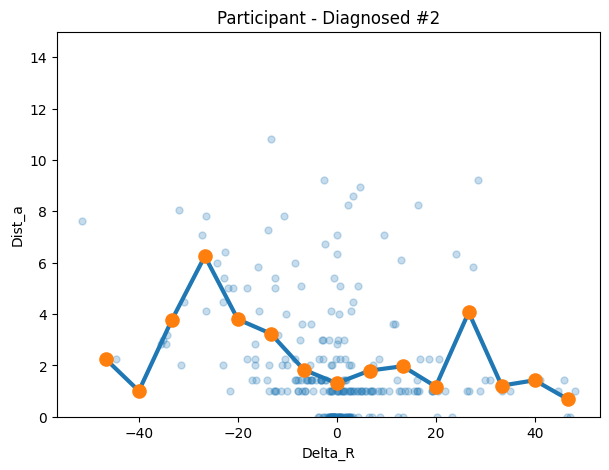

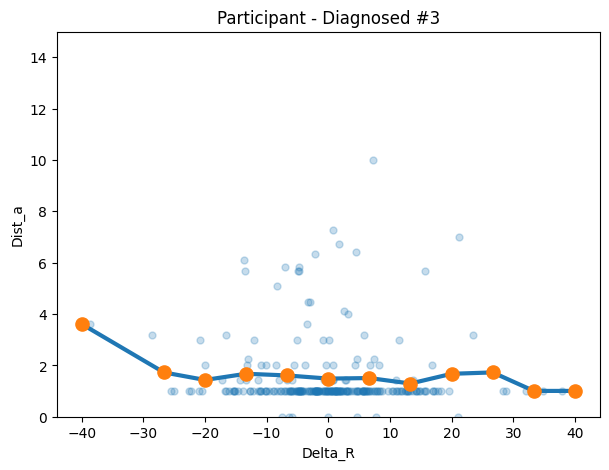

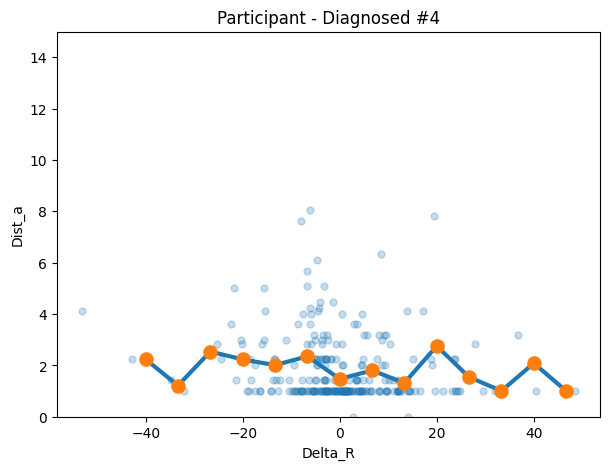

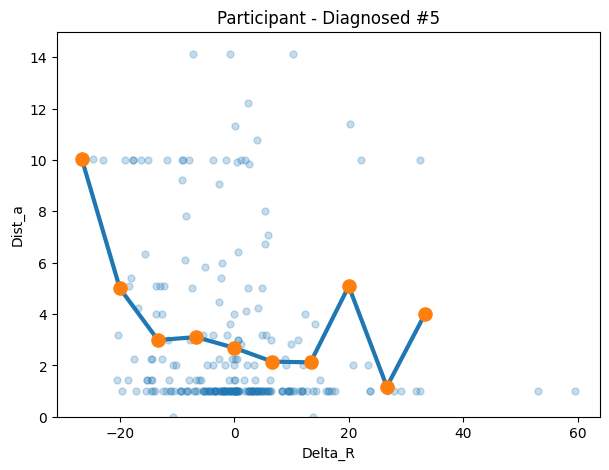

In [45]:
dia1 = make_transition_df("twtzmvq9639ts49wll9c65hq", df=autism_df)

plot_binned_single_participant_fast(
    dia1,
    bin_edges=individual_edges,
    title=f"Participant - Diagnosed #1"
)

dia2 = make_transition_df("qrrzt3mq4ztmmztzszmqsm4s", df=autism_df)

plot_binned_single_participant_fast(
    dia2,
    bin_edges=individual_edges,
    title=f"Participant - Diagnosed #2"
)

dia3 = make_transition_df("5stvthw4vthstq635l6ww4w9", df=autism_df)

plot_binned_single_participant_fast(
    dia3,
    bin_edges=individual_edges,
    title=f"Participant - Diagnosed #3"
)

dia4 = make_transition_df("chtqwhc4shqmc49ztq9lsthv", df=autism_df)

plot_binned_single_participant_fast(
    dia4,
    bin_edges=individual_edges,
    title=f"Participant - Diagnosed #4"
)

dia5 = make_transition_df("6sr9zq3clcw4rzlt5m4wqcc6", df=autism_df)

plot_binned_single_participant_fast(
    dia5,
    bin_edges=individual_edges,
    title=f"Participant - Diagnosed #5"
)

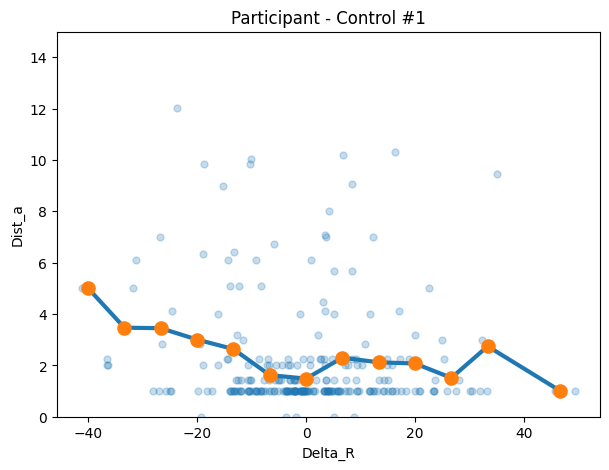

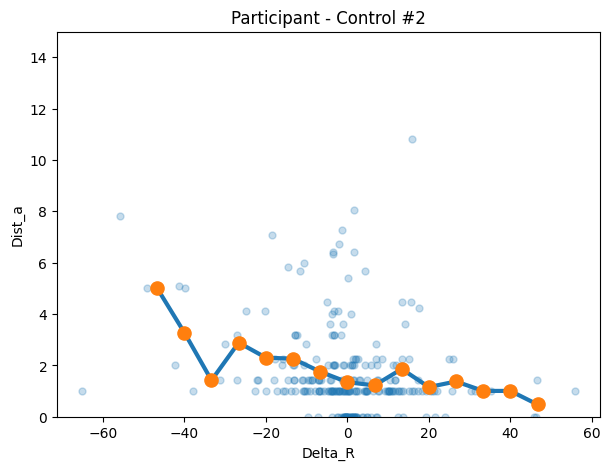

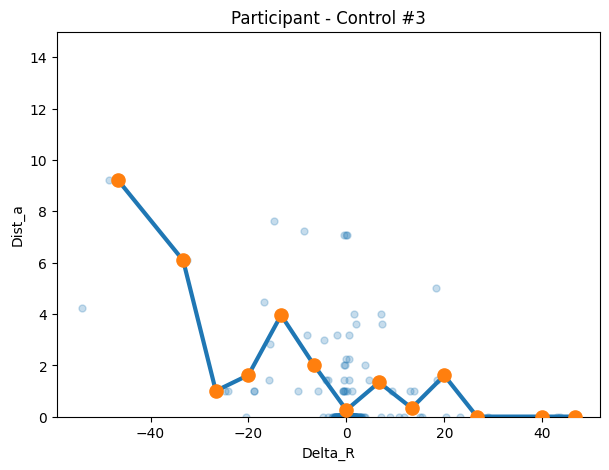

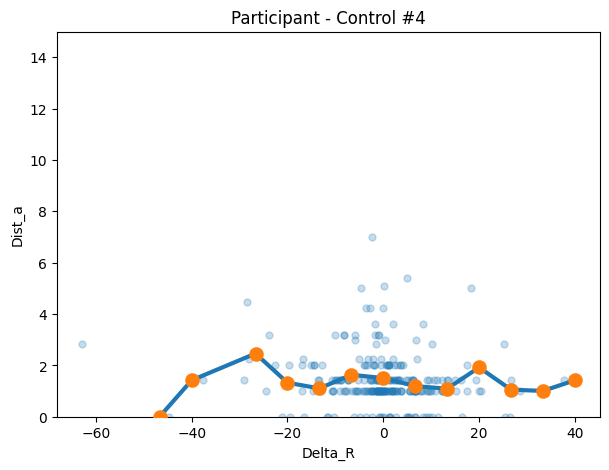

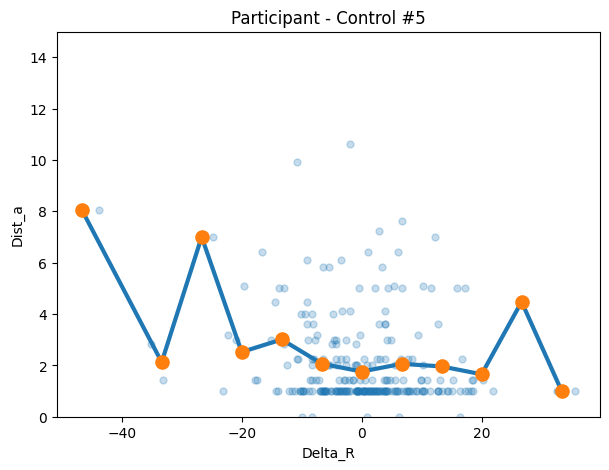

In [46]:
# ['44r44zmrtvl59ml3llcql4w4',
#  'sstr63rwvsmz36hmqs6hzzvs',
#  '4qrwq53mslq4cr4vsrt6946c',
#  '43rzq63t93hsl5ccc9369s5z',
#  '6mtzhvrqrcs3rq3vhhrr5c43']

con1 = make_transition_df("44r44zmrtvl59ml3llcql4w4", df=control_df)

plot_binned_single_participant_fast(
    con1,
    bin_edges=individual_edges,
    title=f"Participant - Control #1"
)

con2 = make_transition_df("sstr63rwvsmz36hmqs6hzzvs", df=control_df)

plot_binned_single_participant_fast(
    con2,
    bin_edges=individual_edges,
    title=f"Participant - Control #2"
)

con3 = make_transition_df("4qrwq53mslq4cr4vsrt6946c", df=control_df)

plot_binned_single_participant_fast(
    con3,
    bin_edges=individual_edges,
    title=f"Participant - Control #3"
)

con4 = make_transition_df("43rzq63t93hsl5ccc9369s5z", df=control_df)

plot_binned_single_participant_fast(
    con4,
    bin_edges=individual_edges,
    title=f"Participant - Control #4"
)

con5 = make_transition_df("6mtzhvrqrcs3rq3vhhrr5c43", df=control_df)

plot_binned_single_participant_fast(
    con5,
    bin_edges=individual_edges,
    title=f"Participant - Control #5"
)

In [47]:
def participant_binned_means_fast(x, y, bin_edges, min_bin_n=1):
    """
    Returns per-bin mean y for ONE participant (length = n_bins), with NaN for bins
    that don't meet min_bin_n.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    n_bins = len(bin_edges) - 1
    if len(x) == 0:
        return np.full(n_bins, np.nan), np.zeros(n_bins, dtype=int)

    idx = np.digitize(x, bin_edges) - 1
    in_range = (idx >= 0) & (idx < n_bins)
    idx = idx[in_range]
    y = y[in_range]

    counts = np.bincount(idx, minlength=n_bins)
    sums = np.bincount(idx, weights=y, minlength=n_bins)

    means = np.full(n_bins, np.nan)
    ok = counts >= min_bin_n
    means[ok] = sums[ok] / counts[ok]

    return means, counts

In [48]:
def group_binned_curve_fast(df_group, subject_col="subjectID",
                           x_col="Delta_R", y_col="Dist_a",
                           bin_edges=None, n_bins=15, x_range=None,
                           min_bin_n=1):
    if bin_edges is None:
        if x_range is None:
            xmin = df_group[x_col].min()
            xmax = df_group[x_col].max()
        else:
            xmin, xmax = x_range
        bin_edges = np.linspace(xmin, xmax, n_bins + 1)
    else:
        bin_edges = np.asarray(bin_edges, dtype=float)

    n_bins = len(bin_edges) - 1
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    curves = []
    for sid, sub in df_group.groupby(subject_col, sort=False):
        means, _ = participant_binned_means_fast(
            sub[x_col].to_numpy(),
            sub[y_col].to_numpy(),
            bin_edges,
            min_bin_n=min_bin_n
        )
        curves.append(means)

    curves = np.asarray(curves)
    group_mean = np.nanmean(curves, axis=0)
    n_subjects_per_bin = np.sum(np.isfinite(curves), axis=0)

    return centers, group_mean, n_subjects_per_bin, bin_edges

In [49]:
def plot_group_overlay_binned(
    autism_df, control_df,
    subject_col="subjectID",
    x_col="Delta_R", y_col="Dist_a",
    bin_edges=None, n_bins=15, x_range=None,
    min_bin_n=3,
    y_range=None,
    title="Group binned movement curves (Autism vs Control)"
):
    # Ensure BOTH groups use identical bin edges
    if bin_edges is None:
        if x_range is None:
            xmin = min(autism_df[x_col].min(), control_df[x_col].min())
            xmax = max(autism_df[x_col].max(), control_df[x_col].max())
        else:
            xmin, xmax = x_range
        bin_edges = np.linspace(xmin, xmax, n_bins + 1)

    # Compute curves
    xa, ya, na, _ = group_binned_curve_fast(
        autism_df, subject_col, x_col, y_col,
        bin_edges=bin_edges, min_bin_n=min_bin_n
    )
    xc, yc, nc, _ = group_binned_curve_fast(
        control_df, subject_col, x_col, y_col,
        bin_edges=bin_edges, min_bin_n=min_bin_n
    )

    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(xa, ya, linewidth=3, label=f"Autism (subjects/bin avg)")
    plt.plot(xc, yc, linewidth=3, label=f"Control (subjects/bin avg)")

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.legend()

    if y_range is not None:
        plt.ylim(y_range)

    plt.show()

    return {
        "centers": xa,
        "autism_mean": ya,
        "control_mean": yc,
        "autism_n_subjects_per_bin": na,
        "control_n_subjects_per_bin": nc,
        "bin_edges": bin_edges
    }

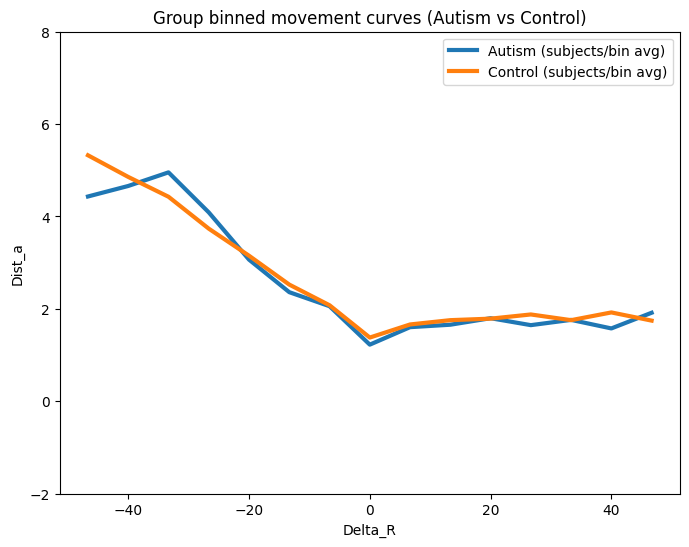

In [50]:
global_y_range = (-2, 8)
GLOBAL_EDGES = np.linspace(-50, 50, 16)

# Create transition dataframes for all participants in each group
autism_transition_list = []
for pid in autism_df["subjectID"].unique():
    transition_data = make_transition_df(pid, df=autism_df)
    if not transition_data.empty:
        autism_transition_list.append(transition_data)
autism_transition_all_df = pd.concat(autism_transition_list) if autism_transition_list else pd.DataFrame()

control_transition_list = []
for pid in control_df["subjectID"].unique():
    transition_data = make_transition_df(pid, df=control_df)
    if not transition_data.empty:
        control_transition_list.append(transition_data)
control_transition_all_df = pd.concat(control_transition_list) if control_transition_list else pd.DataFrame()

out = plot_group_overlay_binned(
    autism_df=autism_transition_all_df,
    control_df=control_transition_all_df,
    subject_col="subjectID",
    x_col="Delta_R",
    y_col="Dist_a",
    bin_edges=GLOBAL_EDGES,
    min_bin_n=3,          # keeps tails
    y_range=global_y_range
)

In [51]:
def build_participant_bin_matrix(
    transition_all_df,          # combined transition df (from all pids)
    bin_edges=GLOBAL_EDGES,
    subject_col="subjectID",
    x_col="Delta_R",
    y_col="Dist_a",
    min_bin_n=1
):
    """
    Builds a (n_participants x n_bins) matrix of per-bin y-averages.

    Rows    = one participant
    Columns = mean Dist_a for each Delta_R bin
    NaN     = participant had no data in that bin (below min_bin_n)
    """
    bin_edges = np.asarray(bin_edges, dtype=float)
    n_bins = len(bin_edges) - 1
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Column labels: bin center values rounded for readability
    col_labels = [f"bin_{c:.1f}" for c in centers]

    rows = {}
    for pid, sub in transition_all_df.groupby(subject_col, sort=False):
        means, _ = participant_binned_means_fast(
            sub[x_col].to_numpy(),
            sub[y_col].to_numpy(),
            bin_edges,
            min_bin_n=min_bin_n
        )
        rows[pid] = means

    matrix_df = pd.DataFrame.from_dict(rows, orient="index", columns=col_labels)
    matrix_df.index.name = subject_col
    return matrix_df

In [52]:
# Build matrix for autism group
autism_bin_matrix = build_participant_bin_matrix(
    autism_transition_all_df,
    bin_edges=GLOBAL_EDGES,
    min_bin_n=1
)

# Build matrix for control group
control_bin_matrix = build_participant_bin_matrix(
    control_transition_all_df,
    bin_edges=GLOBAL_EDGES,
    min_bin_n=1
)

print("Autism matrix shape:", autism_bin_matrix.shape)   # (n_autism_pids, 15)
print("Control matrix shape:", control_bin_matrix.shape) # (n_control_pids, 15)
autism_bin_matrix.head()

Autism matrix shape: (77, 15)
Control matrix shape: (511, 15)


,bin_-46.7,bin_-40.0,bin_-33.3,bin_-26.7,bin_-20.0,bin_-13.3,bin_-6.7,bin_0.0,bin_6.7,bin_13.3,bin_20.0,bin_26.7,bin_33.3,bin_40.0,bin_46.7
subjectID,,,,,,,,,,,,,,,
twtzmvq9639ts49wll9c65hq,4.130649,7.949747,2.768660,1.000000,2.000000,2.081784,1.523819,0.703370,0.847740,0.853143,0.682843,1.000000,1.000000,0.500000,1.000000
qrrzt3mq4ztmmztzszmqsm4s,2.236068,1.000000,3.764789,6.251106,3.791071,3.230729,1.827356,1.299075,1.792903,1.962853,1.170820,4.062509,1.207107,1.414214,0.682843
5stvthw4vthstq635l6ww4w9,NaN,3.605551,NaN,1.720759,1.426777,1.668297,1.602559,1.480145,1.500938,1.287895,1.666667,1.720759,1.000000,1.000000,NaN
chtqwhc4shqmc49ztq9lsthv,NaN,2.236068,1.207107,2.532248,2.227134,2.004737,2.348588,1.466862,1.797534,1.311112,2.749731,1.537570,1.000000,2.081139,1.000000
6sr9zq3clcw4rzlt5m4wqcc6,NaN,NaN,NaN,10.049876,4.996431,2.980674,3.096835,2.679593,2.139761,2.114189,5.080351,1.166667,4.000000,NaN,NaN


In [53]:
def participant_binned_std_fast(x, y, bin_edges, min_bin_n=2):
    """
    Returns per-bin std of y for ONE participant (length = n_bins).
    NaN for bins with fewer than min_bin_n observations.
    Note: min_bin_n defaults to 2 (need at least 2 points for a std).
    """
    x = np.asarray(x)
    y = np.asarray(y)

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    n_bins = len(bin_edges) - 1
    if len(x) == 0:
        return np.full(n_bins, np.nan), np.zeros(n_bins, dtype=int)

    idx = np.digitize(x, bin_edges) - 1
    in_range = (idx >= 0) & (idx < n_bins)
    idx = idx[in_range]
    y = y[in_range]

    counts = np.bincount(idx, minlength=n_bins)
    stds = np.full(n_bins, np.nan)

    for b in range(n_bins):
        if counts[b] >= min_bin_n:
            stds[b] = np.std(y[idx == b], ddof=1)  # ddof=1 = sample std

    return stds, counts


def build_participant_bin_std_matrix(
    transition_all_df,
    bin_edges=GLOBAL_EDGES,
    subject_col="subjectID",
    x_col="Delta_R",
    y_col="Dist_a",
    min_bin_n=2
):
    """
    Builds a (n_participants x n_bins) matrix of per-bin std of y.

    Rows    = one participant
    Columns = std of Dist_a for each Delta_R bin
    NaN     = fewer than min_bin_n observations in that bin
    """
    bin_edges = np.asarray(bin_edges, dtype=float)
    n_bins = len(bin_edges) - 1
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    col_labels = [f"bin_{c:.1f}" for c in centers]

    rows = {}
    for pid, sub in transition_all_df.groupby(subject_col, sort=False):
        stds, _ = participant_binned_std_fast(
            sub[x_col].to_numpy(),
            sub[y_col].to_numpy(),
            bin_edges,
            min_bin_n=min_bin_n
        )
        rows[pid] = stds

    matrix_df = pd.DataFrame.from_dict(rows, orient="index", columns=col_labels)
    matrix_df.index.name = subject_col
    return matrix_df

In [54]:
autism_bin_std_matrix = build_participant_bin_std_matrix(
    autism_transition_all_df,
    bin_edges=GLOBAL_EDGES,
    min_bin_n=2
)

control_bin_std_matrix = build_participant_bin_std_matrix(
    control_transition_all_df,
    bin_edges=GLOBAL_EDGES,
    min_bin_n=2
)

print("Autism std matrix shape:", autism_bin_std_matrix.shape)
autism_bin_std_matrix.head()

Autism std matrix shape: (77, 15)


,bin_-46.7,bin_-40.0,bin_-33.3,bin_-26.7,bin_-20.0,bin_-13.3,bin_-6.7,bin_0.0,bin_6.7,bin_13.3,bin_20.0,bin_26.7,bin_33.3,bin_40.0,bin_46.7
subjectID,,,,,,,,,,,,,,,
twtzmvq9639ts49wll9c65hq,1.369483,2.757359,1.915476,NaN,0.000000,1.507379,0.747884,1.709049,0.542894,0.597459,0.645877,NaN,0.000000,0.707107,NaN
qrrzt3mq4ztmmztzszmqsm4s,NaN,NaN,2.032426,1.601531,1.922898,2.600145,1.370581,2.001928,2.232688,2.215041,0.836115,3.548976,0.239146,NaN,0.645877
5stvthw4vthstq635l6ww4w9,NaN,NaN,NaN,1.248392,0.728449,1.313213,1.506911,1.334436,1.701337,0.977230,2.061553,1.248392,0.000000,NaN,NaN
chtqwhc4shqmc49ztq9lsthv,NaN,NaN,0.292893,0.418861,1.282132,1.216489,1.729965,0.904898,1.156759,0.821778,2.314915,0.764107,NaN,1.528961,NaN
6sr9zq3clcw4rzlt5m4wqcc6,NaN,NaN,NaN,NaN,3.757923,2.796326,3.517218,3.151195,2.215321,2.925186,5.170836,0.408248,5.196152,NaN,NaN


In [55]:
def group_binned_curve_with_se(df_group, subject_col="subjectID",
                                x_col="Delta_R", y_col="Dist_a",
                                bin_edges=None, n_bins=15, x_range=None,
                                min_bin_n=1):
    """
    Same as group_binned_curve_fast but also returns per-bin std and SE
    across participants (for error bars on the group plot).
    """
    if bin_edges is None:
        if x_range is None:
            xmin = df_group[x_col].min()
            xmax = df_group[x_col].max()
        else:
            xmin, xmax = x_range
        bin_edges = np.linspace(xmin, xmax, n_bins + 1)
    else:
        bin_edges = np.asarray(bin_edges, dtype=float)

    n_bins = len(bin_edges) - 1
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    curves = []
    for sid, sub in df_group.groupby(subject_col, sort=False):
        means, _ = participant_binned_means_fast(
            sub[x_col].to_numpy(),
            sub[y_col].to_numpy(),
            bin_edges,
            min_bin_n=min_bin_n
        )
        curves.append(means)

    curves = np.asarray(curves)                          # (n_subjects, n_bins)
    group_mean = np.nanmean(curves, axis=0)
    group_std  = np.nanstd(curves, axis=0, ddof=1)      # std across participants
    n_per_bin  = np.sum(np.isfinite(curves), axis=0)    # valid subjects per bin
    group_se   = group_std / np.sqrt(n_per_bin)         # standard error

    return centers, group_mean, group_std, group_se, n_per_bin, bin_edges


def plot_group_overlay_binned_errorbars(
    autism_df, control_df,
    subject_col="subjectID",
    x_col="Delta_R", y_col="Dist_a",
    bin_edges=None, n_bins=15, x_range=None,
    min_bin_n=1,
    error_type="sd",        # "sd" for std dev, "se" for standard error
    alpha_fill=0.18,        # shaded band transparency
    y_range=None,
    title="Group binned movement curves (Autism vs Control)"
):
    if bin_edges is None:
        if x_range is None:
            xmin = min(autism_df[x_col].min(), control_df[x_col].min())
            xmax = max(autism_df[x_col].max(), control_df[x_col].max())
        else:
            xmin, xmax = x_range
        bin_edges = np.linspace(xmin, xmax, n_bins + 1)

    xa, ya, ya_sd, ya_se, na, _ = group_binned_curve_with_se(
        autism_df, subject_col, x_col, y_col,
        bin_edges=bin_edges, min_bin_n=min_bin_n
    )
    xc, yc, yc_sd, yc_se, nc, _ = group_binned_curve_with_se(
        control_df, subject_col, x_col, y_col,
        bin_edges=bin_edges, min_bin_n=min_bin_n
    )

    y_err_a = ya_sd if error_type == "sd" else ya_se
    y_err_c = yc_sd if error_type == "sd" else yc_se
    err_label = "±1 SD" if error_type == "sd" else "±1 SE"

    fig, ax = plt.subplots(figsize=(9, 6))

    # Autism
    ax.plot(xa, ya, linewidth=3, label=f"Autism ({err_label})", color="tab:blue")
    ax.fill_between(xa, ya - y_err_a, ya + y_err_a, alpha=alpha_fill, color="tab:blue")

    # Control
    ax.plot(xc, yc, linewidth=3, label=f"Control ({err_label})", color="tab:orange")
    ax.fill_between(xc, yc - y_err_c, yc + y_err_c, alpha=alpha_fill, color="tab:orange")

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    ax.legend()

    if y_range is not None:
        ax.set_ylim(y_range)

    plt.tight_layout()
    plt.show()

    return {
        "centers": xa,
        "autism_mean": ya, "autism_sd": ya_sd, "autism_se": ya_se,
        "control_mean": yc, "control_sd": yc_sd, "control_se": yc_se,
        "autism_n_per_bin": na, "control_n_per_bin": nc,
        "bin_edges": bin_edges
    }

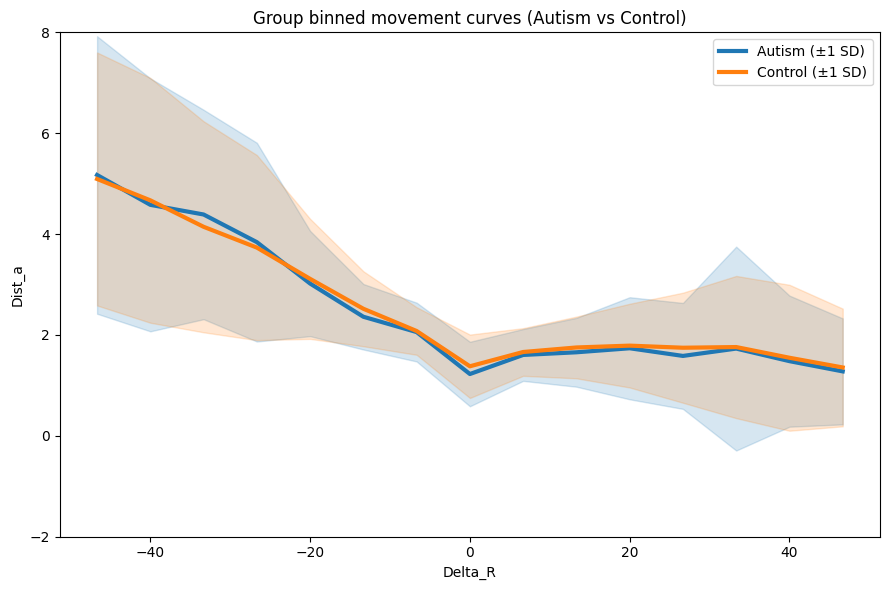

In [56]:
out = plot_group_overlay_binned_errorbars(
    autism_df=autism_transition_all_df,
    control_df=control_transition_all_df,
    subject_col="subjectID",
    x_col="Delta_R",
    y_col="Dist_a",
    bin_edges=GLOBAL_EDGES,
    min_bin_n=1,
    error_type="sd",        # swap to "se" for standard error instead
    y_range=global_y_range
)

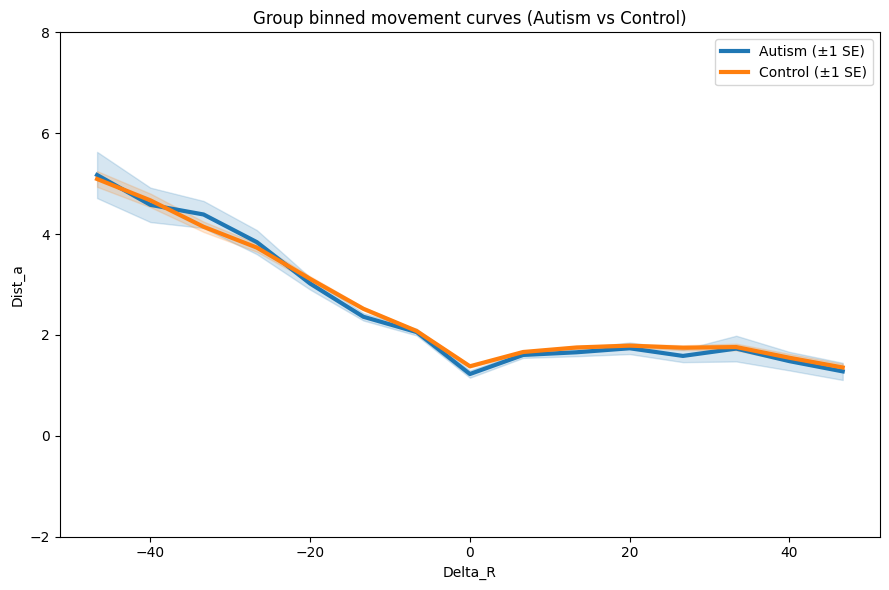

In [57]:
out = plot_group_overlay_binned_errorbars(
    autism_df=autism_transition_all_df,
    control_df=control_transition_all_df,
    subject_col="subjectID",
    x_col="Delta_R",
    y_col="Dist_a",
    bin_edges=GLOBAL_EDGES,
    min_bin_n=1,
    error_type="se",
    y_range=global_y_range
)

Both groups travel further after large negative reward changes, converging to shorter distances near 0
Diagnosed = slightly higher distance on negative end, SD bands are wide = lots of variability (expected.)

Trial position could inflate/confound the negative tail, not letting us see whether there is a difference...


Try residualizing this.

In [58]:
def residualize_dist_by_trial(transition_df, dist_col="Dist_a", trial_col="trial"):
    # regress Dist_a on trial number and return residuals.
    # represent movement unexplained by trial position alone
    df = transition_df.copy().reset_index(drop=True)
    df["Dist_a_resid"] = np.nan

    for pid, sub in df.groupby("subjectID"):
        sub = sub.reset_index(drop=True)
        X = sub[[trial_col]].to_numpy()
        y = sub[dist_col].to_numpy()

        mask = np.isfinite(X.flatten()) & np.isfinite(y)
        if mask.sum() < 3:
            continue

        reg = LinearRegression().fit(X[mask], y[mask])

        # valid rows for residuals are computed
        residuals = np.full(len(y), np.nan)
        residuals[mask] = y[mask] - reg.predict(X[mask])

        # Original index from the df is used to assign back correctly
        df.loc[sub.index, "Dist_a_resid"] = residuals

    return df

In [59]:
autism_transition_all_df = residualize_dist_by_trial(autism_transition_all_df)
control_transition_all_df = residualize_dist_by_trial(control_transition_all_df)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3499/4127031917.py:33: RuntimeWarning: Mean of empty slice
  group_mean = np.nanmean(curves, axis=0)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


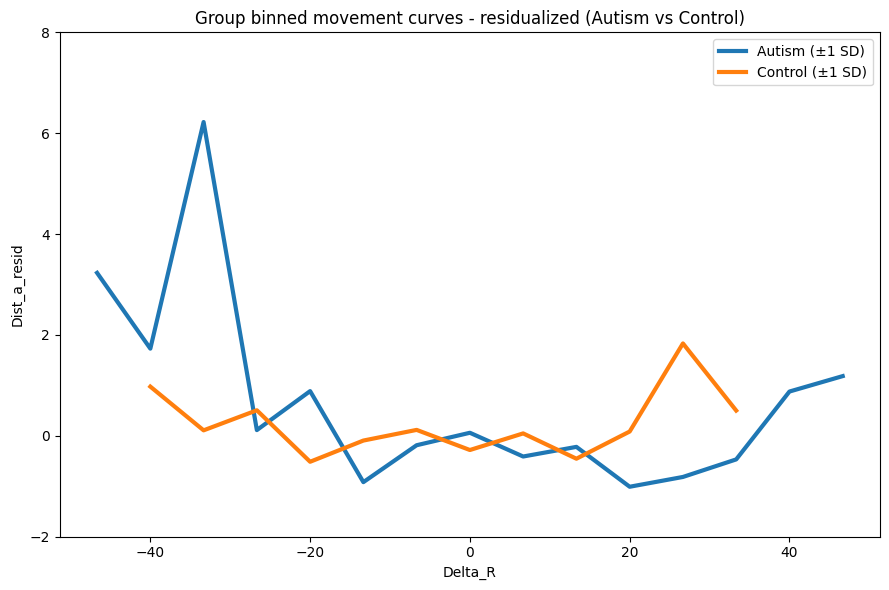

In [60]:
out_resid = plot_group_overlay_binned_errorbars(
    autism_df=autism_transition_all_df,
    control_df=control_transition_all_df,
    subject_col="subjectID",
    x_col="Delta_R",
    y_col="Dist_a_resid",        # new residualized values
    bin_edges=GLOBAL_EDGES,
    min_bin_n=1,
    error_type="sd",
    y_range=global_y_range,
    title="Group binned movement curves - residualized (Autism vs Control)"
)

Whoa! Way different than what we originally had. However, we need the error bars. The SD values were probably lost, let's check that.

In [61]:
print("Autism SD:", out_resid["autism_sd"])
print("Control SD:", out_resid["control_sd"])

Autism SD: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
Control SD: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]


Yikes. How many participants is there per bin? Maybe that's what causing the null. Maybe it's the amount of bins?

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3499/4127031917.py:33: RuntimeWarning: Mean of empty slice
  group_mean = np.nanmean(curves, axis=0)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


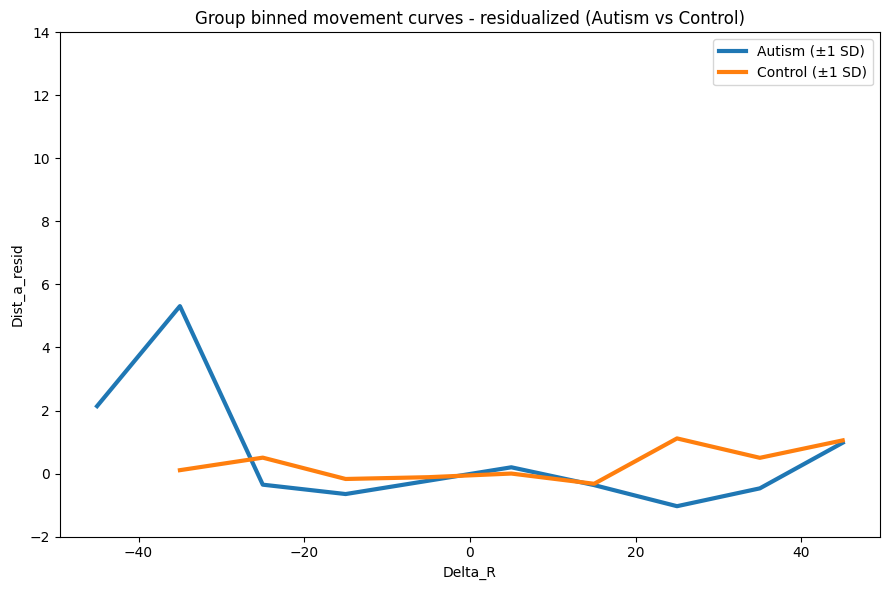

In [63]:
RESID_EDGES = np.linspace(-50, 50, 11)  # 10 wider bins instead of 15

out_resid = plot_group_overlay_binned_errorbars(
    autism_df=autism_transition_all_df,
    control_df=control_transition_all_df,
    subject_col="subjectID",
    x_col="Delta_R",
    y_col="Dist_a_resid",
    bin_edges=RESID_EDGES,       # new wider bins
    min_bin_n=2,
    error_type="sd",
    y_range=(-2, 14),
    title="Group binned movement curves - residualized (Autism vs Control)"
)

Did not do much, best to scrap this. We'll need to go through each bin and check each N.

In [64]:
def diagnose_bin_coverage(df, bin_edges, subject_col="subjectID", x_col="Delta_R", y_col="Dist_a_resid"):
    n_bins = len(bin_edges) - 1
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    coverage = []
    for pid, sub in df.groupby(subject_col):
        means, counts = participant_binned_means_fast(
            sub[x_col].to_numpy(),
            sub[y_col].to_numpy(),
            bin_edges,
            min_bin_n=1
        )
        coverage.append(np.isfinite(means).astype(int))
    coverage = np.array(coverage)
    n_participants_per_bin = coverage.sum(axis=0)
    for i, (c, n) in enumerate(zip(centers, n_participants_per_bin)):
        print(f"Bin center {c:.1f}: {n} participants")

print("Diagnosed")
diagnose_bin_coverage(autism_transition_all_df, RESID_EDGES)
print("\n Control")
diagnose_bin_coverage(control_transition_all_df, RESID_EDGES)

=== AUTISM ===
Bin center -45.0: 1 participants
Bin center -35.0: 1 participants
Bin center -25.0: 1 participants
Bin center -15.0: 1 participants
Bin center -5.0: 1 participants
Bin center 5.0: 1 participants
Bin center 15.0: 1 participants
Bin center 25.0: 1 participants
Bin center 35.0: 1 participants
Bin center 45.0: 1 participants

=== CONTROL ===
Bin center -45.0: 1 participants
Bin center -35.0: 1 participants
Bin center -25.0: 1 participants
Bin center -15.0: 1 participants
Bin center -5.0: 1 participants
Bin center 5.0: 1 participants
Bin center 15.0: 1 participants
Bin center 25.0: 1 participants
Bin center 35.0: 1 participants
Bin center 45.0: 1 participants


No wonder...

In [68]:
# New fixed residualization function
def residualize_dist_by_trial(transition_df, dist_col="Dist_a", trial_col="trial"):
    df = transition_df.copy().reset_index(drop=True)
    df["Dist_a_resid"] = np.nan

    for pid, sub in df.groupby("subjectID"):
        original_index = sub.index  # save BEFORE resetting
        sub = sub.reset_index(drop=True)

        X = sub[[trial_col]].to_numpy()
        y = sub[dist_col].to_numpy()

        mask = np.isfinite(X.flatten()) & np.isfinite(y)
        if mask.sum() < 3:
            continue

        reg = LinearRegression().fit(X[mask], y[mask])

        residuals = np.full(len(y), np.nan)
        residuals[mask] = y[mask] - reg.predict(X[mask])

        df.loc[original_index, "Dist_a_resid"] = residuals

    return df

# rebuild the full concatenated transition dataframes fresh
autism_transition_list = []
for pid in autism_df["subjectID"].unique():
    transition_data = make_transition_df(pid, df=autism_df)
    if not transition_data.empty:
        autism_transition_list.append(transition_data)
autism_transition_all_df = pd.concat(autism_transition_list).reset_index(drop=True)

control_transition_list = []
for pid in control_df["subjectID"].unique():
    transition_data = make_transition_df(pid, df=control_df)
    if not transition_data.empty:
        control_transition_list.append(transition_data)
control_transition_all_df = pd.concat(control_transition_list).reset_index(drop=True)

# apply residualization
autism_transition_all_df = residualize_dist_by_trial(autism_transition_all_df)
control_transition_all_df = residualize_dist_by_trial(control_transition_all_df)

# verify
print("Autism participants:", autism_transition_all_df["subjectID"].nunique())
print("Control participants:", control_transition_all_df["subjectID"].nunique())
print("Autism NaN in Dist_a_resid:", autism_transition_all_df["Dist_a_resid"].isna().sum())
print("Control NaN in Dist_a_resid:", control_transition_all_df["Dist_a_resid"].isna().sum())

Autism participants: 77
Control participants: 511
Autism NaN in Dist_a_resid: 0
Control NaN in Dist_a_resid: 0


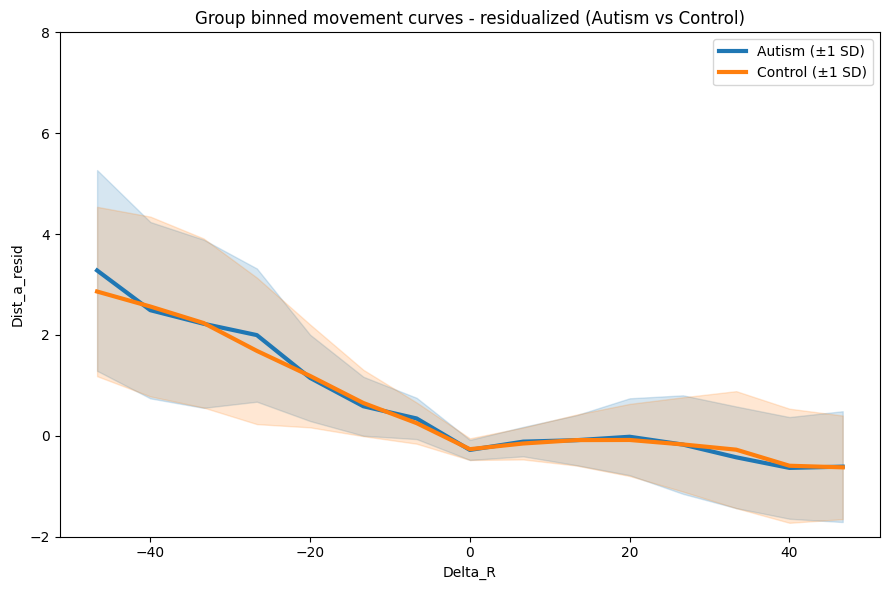

In [69]:
out_resid = plot_group_overlay_binned_errorbars(
    autism_df=autism_transition_all_df,
    control_df=control_transition_all_df,
    subject_col="subjectID",
    x_col="Delta_R",
    y_col="Dist_a_resid",
    bin_edges=GLOBAL_EDGES,
    min_bin_n=2,
    error_type="sd",
    y_range=global_y_range,
    title="Group binned movement curves - residualized (Autism vs Control)"
)